# Flow Matching on a 1D Gaussian Mixture

This notebook applies **Conditional Flow Matching (I-CFM)** to a simple 1D problem:

- **Source** $p_0$: standard Gaussian $\mathcal{N}(0, 1)$
- **Target** $p_1$: mixture of two tight Gaussians $\frac{1}{2}\mathcal{N}(-2,\, 0.01) + \frac{1}{2}\mathcal{N}(+2,\, 0.01)$

The low target variance makes the two modes very sharp, which is a clean stress-test for the vector field.

After training we visualise:
1. Source vs target distributions
2. Particle trajectories in the $(t, x)$ plane
3. The learned vector field $v_\theta(t, x)$ as a 2-D heatmap

In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchdyn.core import NeuralODE

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchcfm.models.models import MLP
from torchcfm.utils import torch_wrapper

torch.manual_seed(0)
np.random.seed(0)

## Distributions

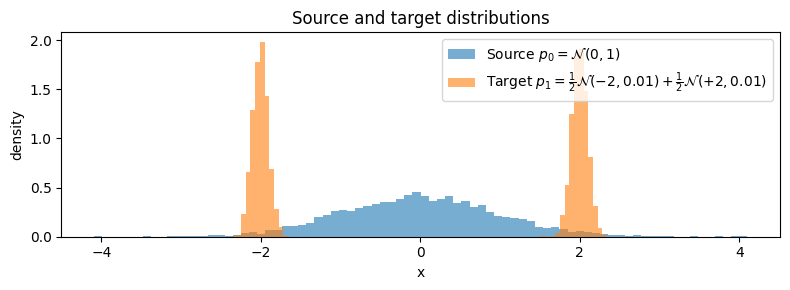

In [2]:
STD_TARGET = 0.1   # std of each mode  (variance = 0.01)
CENTERS    = [-2.0, 2.0]


def sample_source(n: int) -> torch.Tensor:
    """Standard Gaussian, shape (n, 1)."""
    return torch.randn(n, 1)


def sample_target(n: int) -> torch.Tensor:
    """Equal mixture of N(-2, 0.01) and N(+2, 0.01), shape (n, 1)."""
    component = torch.randint(0, 2, (n,))
    means     = torch.where(component == 0,
                            torch.tensor(CENTERS[0]),
                            torch.tensor(CENTERS[1]))
    return (means + STD_TARGET * torch.randn(n)).unsqueeze(1)


# --- visualise ---
x_src = sample_source(4000).numpy()
x_tgt = sample_target(4000).numpy()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(x_src, bins=80, density=True, alpha=0.6, label=r'Source $p_0 = \mathcal{N}(0,1)$')
ax.hist(x_tgt, bins=80, density=True, alpha=0.6,
        label=r'Target $p_1 = \frac{1}{2}\mathcal{N}(-2,0.01)+\frac{1}{2}\mathcal{N}(+2,0.01)$')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Source and target distributions')
plt.tight_layout()
plt.show()

## Training: Independent CFM (I-CFM)

We use the standard I-CFM objective
$$
\mathcal{L}(\theta) = \mathbb{E}_{t,\, x_0 \sim p_0,\, x_1 \sim p_1} \|v_\theta(t,\, x_t) - (x_1 - x_0)\|^2
$$
where $x_t = (1-t)x_0 + t x_1 + \sigma \epsilon$, $\epsilon \sim \mathcal{N}(0,I)$.

The network is a small 1-D MLP: input $(x, t) \in \mathbb{R}^2$, output $v \in \mathbb{R}$.

iter   2000 | loss 2.4388 | elapsed 12.4s
iter   4000 | loss 2.1579 | elapsed 24.6s
iter   6000 | loss 2.2058 | elapsed 36.8s
iter   8000 | loss 2.2119 | elapsed 49.3s
iter  10000 | loss 1.7146 | elapsed 61.7s


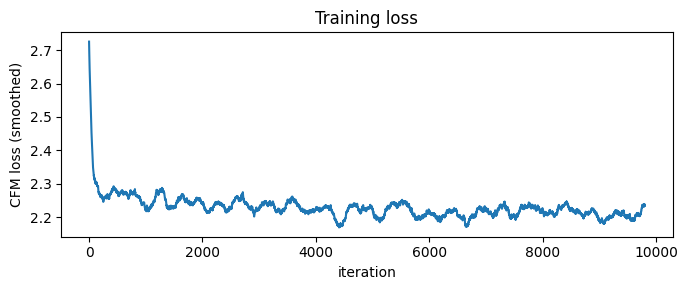

In [3]:
DIM        = 1
SIGMA      = 0.01      # small noise on the probability path
BATCH_SIZE = 512
N_ITER     = 10000
LR         = 1e-3

model     = MLP(dim=DIM, time_varying=True, w=128)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
FM        = ConditionalFlowMatcher(sigma=SIGMA)

losses = []
t0 = time.time()

for k in range(N_ITER):
    optimizer.zero_grad()

    x0 = sample_source(BATCH_SIZE)
    x1 = sample_target(BATCH_SIZE)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt   = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (k + 1) % 2000 == 0:
        print(f"iter {k+1:>6d} | loss {loss.item():.4f} | elapsed {time.time()-t0:.1f}s")

# plot training curve
fig, ax = plt.subplots(figsize=(7, 3))
window = 200
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
ax.plot(smoothed)
ax.set_xlabel('iteration')
ax.set_ylabel('CFM loss (smoothed)')
ax.set_title('Training loss')
plt.tight_layout()
plt.show()

## Sampling via ODE integration

We solve $\dot{x} = v_\theta(t, x)$ forward in time using `torchdyn`'s `NeuralODE`.

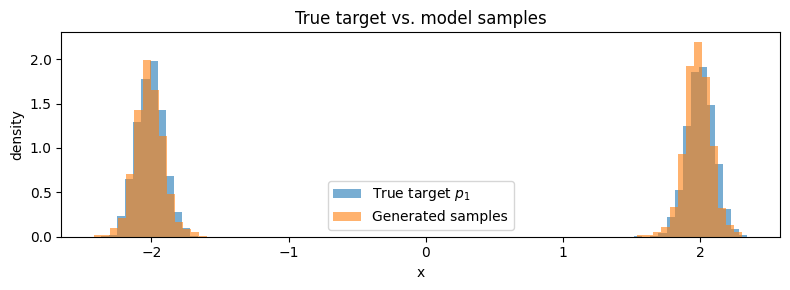

In [4]:
node = NeuralODE(
    torch_wrapper(model),
    solver="dopri5",
    sensitivity="adjoint",
    atol=1e-5,
    rtol=1e-5,
)

N_SAMPLES  = 2000
T_SPAN     = torch.linspace(0, 1, 100)

with torch.no_grad():
    x_init = sample_source(N_SAMPLES)          # shape (N, 1)
    traj   = node.trajectory(x_init, t_span=T_SPAN)   # shape (100, N, 1)

traj_np = traj.cpu().numpy()   # (T, N, 1)
t_np    = T_SPAN.numpy()       # (T,)

# compare generated samples with the true target
gen = traj_np[-1, :, 0]        # final positions

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(x_tgt,        bins=80, density=True, alpha=0.6, label='True target $p_1$')
ax.hist(gen[:, None], bins=80, density=True, alpha=0.6, label='Generated samples')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
ax.set_title('True target vs. model samples')
plt.tight_layout()
plt.show()

## Particle trajectories in the $(t, x)$ plane

Each line is one particle transported from $p_0$ to $p_1$.

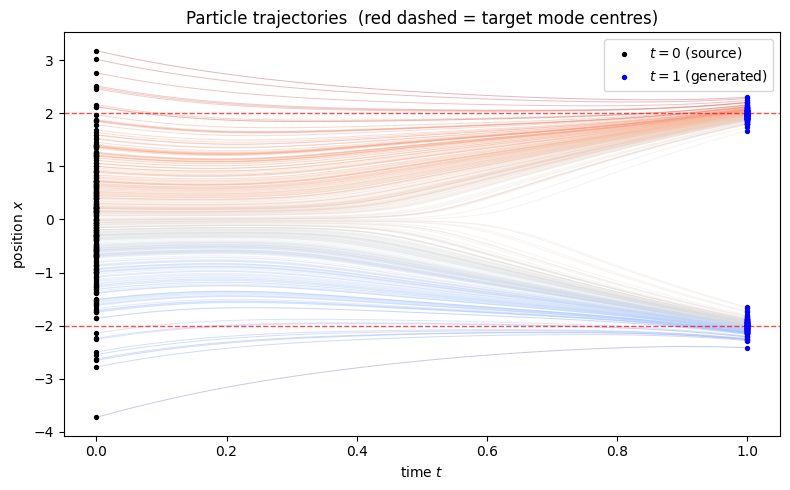

In [5]:
N_SHOW = 300   # number of trajectories to draw

fig, ax = plt.subplots(figsize=(8, 5))

# colour by starting position
x_start = traj_np[0, :N_SHOW, 0]   # (N_SHOW,)
vmin, vmax = x_start.min(), x_start.max()

for i in range(N_SHOW):
    c = plt.cm.coolwarm((x_start[i] - vmin) / (vmax - vmin + 1e-8))
    ax.plot(t_np, traj_np[:, i, 0], color=c, alpha=0.3, linewidth=0.7)

# mark start and end
ax.scatter(np.zeros(N_SHOW),  traj_np[0,  :N_SHOW, 0], s=8, c='black', zorder=3, label='$t=0$ (source)')
ax.scatter(np.ones(N_SHOW),   traj_np[-1, :N_SHOW, 0], s=8, c='blue',  zorder=3, label='$t=1$ (generated)')

# reference lines for the target modes
for c_val in CENTERS:
    ax.axhline(c_val, color='red', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('time $t$')
ax.set_ylabel('position $x$')
ax.set_title('Particle trajectories  (red dashed = target mode centres)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Learned vector field $v_\theta(t, x)$

We evaluate the trained network on a fine $(t, x)$ grid and display it two ways:

1. **Heatmap** – colour = $v_\theta(t, x)$ value (positive = rightward push, negative = leftward)
2. **Quiver plot** – arrows show direction and magnitude at each grid point

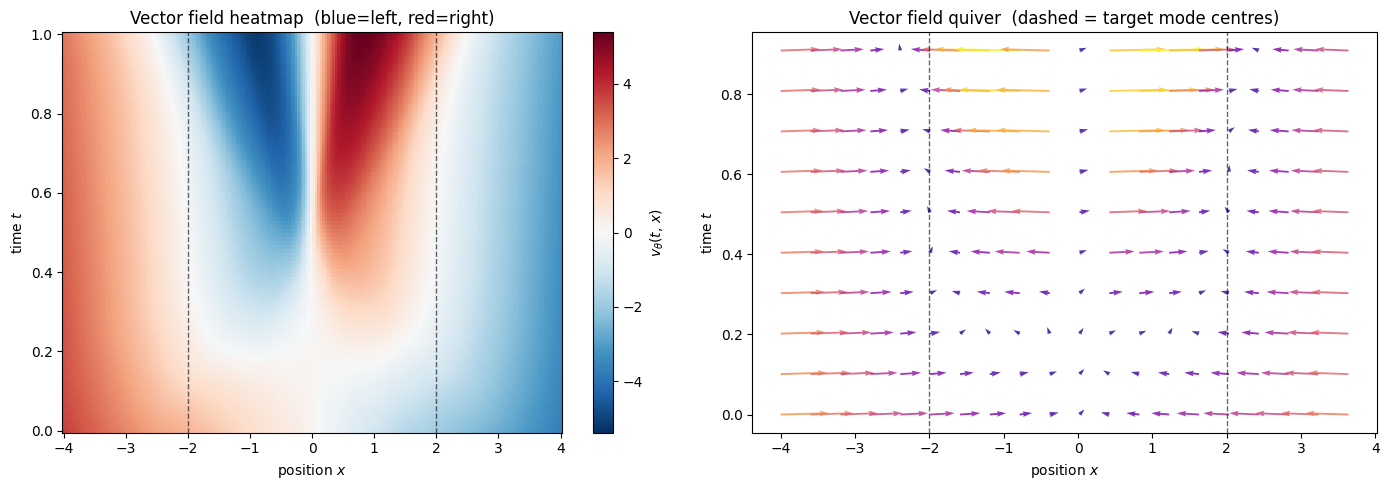

In [6]:
model.eval()

x_grid = np.linspace(-4, 4, 200)
t_grid = np.linspace(0, 1, 100)

XX, TT = np.meshgrid(x_grid, t_grid)   # (T, X)

x_flat = torch.tensor(XX.ravel(), dtype=torch.float32).unsqueeze(1)  # (T*X, 1)
t_flat = torch.tensor(TT.ravel(), dtype=torch.float32).unsqueeze(1)  # (T*X, 1)

with torch.no_grad():
    vf_flat = model(torch.cat([x_flat, t_flat], dim=1)).numpy()  # (T*X, 1)

VV = vf_flat.reshape(XX.shape)   # (T, X)

# --- heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
vabs = np.abs(VV).max()
im = ax.pcolormesh(x_grid, t_grid, VV,
                   cmap='RdBu_r', vmin=-vabs, vmax=vabs, shading='auto')
plt.colorbar(im, ax=ax, label=r'$v_\theta(t,\,x)$')
for c_val in CENTERS:
    ax.axvline(c_val, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('position $x$')
ax.set_ylabel('time $t$')
ax.set_title('Vector field heatmap  (blue=left, red=right)')

# --- quiver ---
ax = axes[1]
# subsample for readability
sx, st = 10, 10
Xq = XX[::st, ::sx]
Tq = TT[::st, ::sx]
Vq = VV[::st, ::sx]
Uq = np.ones_like(Vq) * 0.1   # dt component (constant, small)

ax.quiver(Xq, Tq, Vq, Uq,
          np.abs(Vq), cmap='plasma',
          scale=None, scale_units='xy',
          width=0.003, alpha=0.8)
for c_val in CENTERS:
    ax.axvline(c_val, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('position $x$')
ax.set_ylabel('time $t$')
ax.set_title('Vector field quiver  (dashed = target mode centres)')

plt.tight_layout()
plt.show()

## Vector field slices at fixed $t$

Plotting $v_\theta(t, \cdot)$ as a 1-D curve at several time steps makes the dynamics easy to read:
- At $t=0$ the field pushes mass away from the crowded centre of $p_0$.
- At $t=1$ the field is near zero everywhere except close to the two modes, where it converges inward.

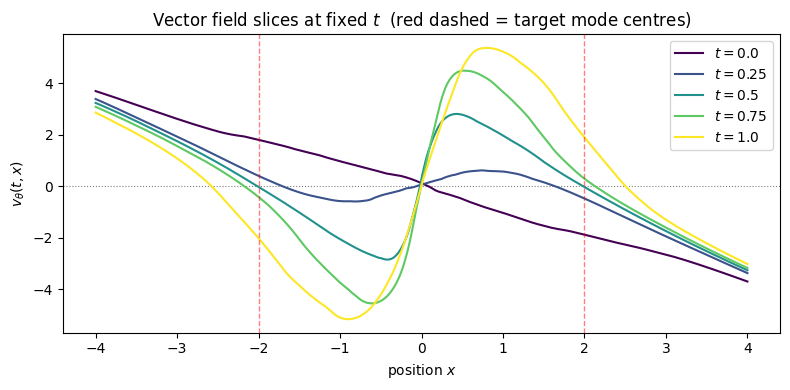

In [7]:
T_SLICES = [0.0, 0.25, 0.5, 0.75, 1.0]
colors   = plt.cm.viridis(np.linspace(0, 1, len(T_SLICES)))

x_line = torch.linspace(-4, 4, 400).unsqueeze(1)   # (400, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

for t_val, col in zip(T_SLICES, colors):
    t_line = torch.full((400, 1), t_val)
    with torch.no_grad():
        v_line = model(torch.cat([x_line, t_line], dim=1)).numpy().ravel()
    ax.plot(x_line.numpy().ravel(), v_line, color=col, label=f'$t={t_val}$')

for c_val in CENTERS:
    ax.axvline(c_val, color='red', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('position $x$')
ax.set_ylabel(r'$v_\theta(t, x)$')
ax.set_title('Vector field slices at fixed $t$  (red dashed = target mode centres)')
ax.legend()
plt.tight_layout()
plt.show()